In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Samuele Taviano
# Matricole: 660185,

In [2]:
import importlib
from sklearn.model_selection import StratifiedKFold
import wine_common as wine
import knn_common as kc
from sklearn.metrics import ConfusionMatrixDisplay, classification_report



In [3]:
importlib.reload(wine)
importlib.reload(kc)

<module 'knn_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/collaudo/knn_common.py'>

In [4]:
# Split for KFold
n_split = 5
default_cv = StratifiedKFold(n_splits=n_split, shuffle=True, random_state=42)

default_krange = list(range(1, 41, 2))

default_random_state = 42

# Subset is derived from data analysis
# and feature selection, more for learning purpose
# than for real needs as the numner of features is small
subset_features_1 = [
    'alcohol',
    'volatile acidity',
    'sulphates',
    'citric acid',
    'total sulfur dioxide'
]


<h2>Wine Dataset</h2>
<hr/>

<h4>Data Loading</h4>
<p>Load and introspect data from monk training and test set.</p>

In [5]:
importlib.reload(wine)
df_train, df_test = wine.stratified_split(type='white', seed=default_random_state)
X_tr_full, y_tr, X_ts, y_ts = wine.split_and_prepare_dataset(df_train, df_test)
X_tr = X_tr_full[subset_features_1]
X_ts = X_ts[subset_features_1]
wine.dataset_introspection(df_train, df_test)

,Property,Training,Test
0,Number of samples,3919,979
1,Number of features,11,11
2,Class values,"[3, 4, 5, 6, 7, 8, 9]","[3, 4, 5, 6, 7, 8]"
3,Class balance,"quality 3 = 15, quality 4 = 138, quality 5 = 1...","quality 3 = 5, quality 4 = 25, quality 5 = 291..."


In [32]:
weights = "uniform"
metric = "euclidean"
model, cv_scores, train_scores = kc.find_best_knn_model(
    X_tr, y_tr, default_cv, default_krange,weights=weights,metric=metric
)

best_k, best_mean, best_std = kc.knn_introspection(cv_scores)


Best k: 1
Best mean accuracy: 0.5756545338441891
Std: 0.00875890929471594


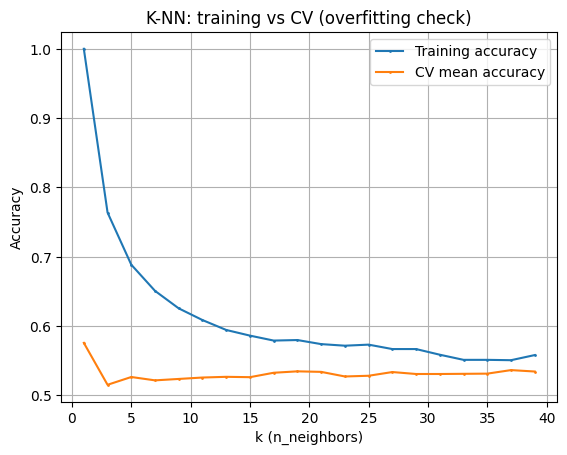

In [33]:
kc.plot_knn_validation_curve(cv_scores, train_scores)

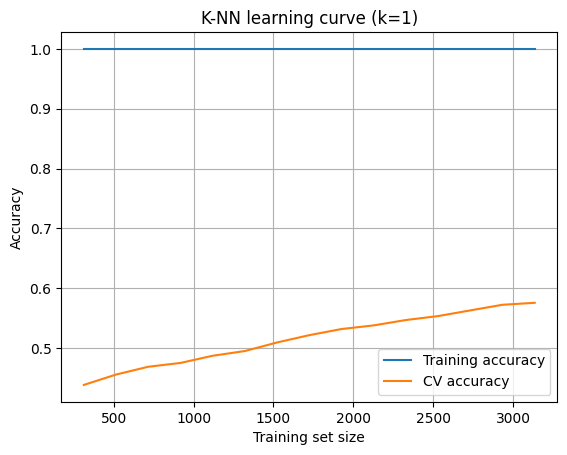

In [34]:
kc.plot_knn_learning_curve(model, X_tr, y_tr, default_cv)

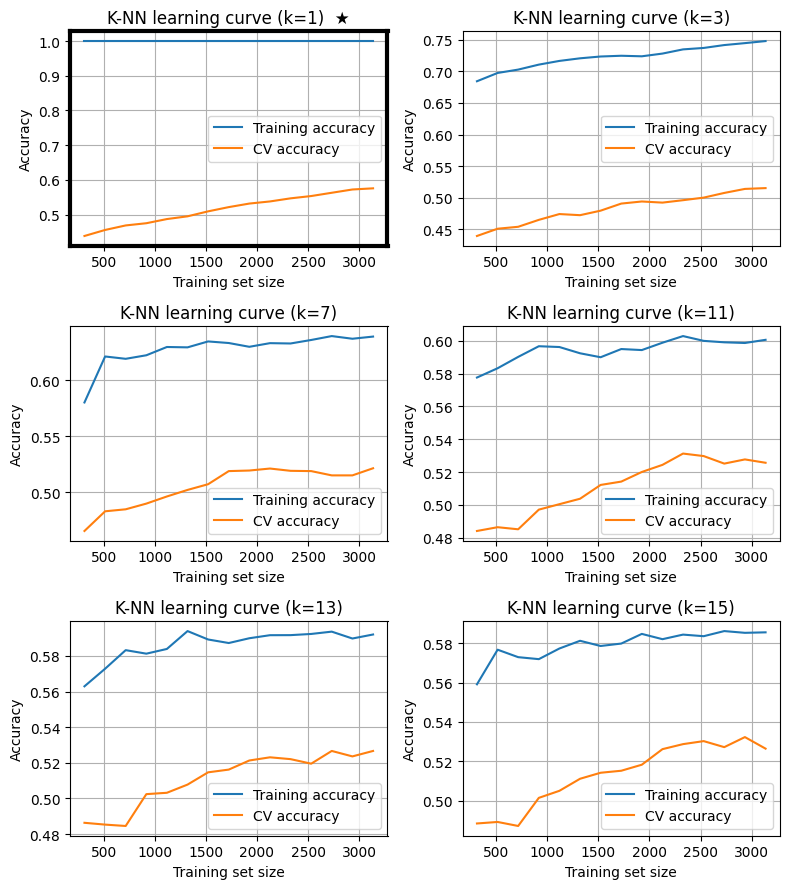

In [46]:
importlib.reload(kc)
models=[]
for k in kc.k_neighborhood(best_k, len(y_tr)):
    models.append(KNeighborsClassifier(
        n_neighbors=k,
        weights=weights,
        metric=metric
    ))

kc.plot_knn_learning_curves_grid(
    models=models,
    X=X_tr,
    y=y_tr,
    cv=default_cv,
    highlight_k=best_k
)

<h4>Prediction</h4>
<p>Performing a prediction on the test set</p>

In [8]:
model.fit(X_tr, y_tr)
y_pred = model.predict(X_ts)

In [9]:
print(classification_report(y_ts, y_pred, zero_division=0))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         5
           4       0.05      0.28      0.09        25
           5       0.39      0.43      0.41       291
           6       0.48      0.43      0.46       431
           7       0.35      0.17      0.23       192
           8       0.11      0.11      0.11        35
           9       0.00      0.00      0.00         0

    accuracy                           0.36       979
   macro avg       0.20      0.20      0.19       979
weighted avg       0.40      0.36      0.37       979



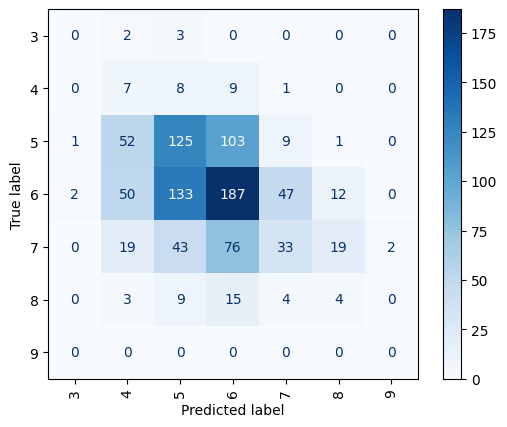

In [10]:
ConfusionMatrixDisplay.from_predictions(y_ts, y_pred, xticks_rotation='vertical', cmap='Blues');